# 🟠 Lesson 16 — PyKrige

**Level: Advanced** · Geostatistical interpolation — kriging gives you both an estimate *and* its uncertainty, unlike IDW/splines.

*Part of the companion package for [python_for_geologists](https://github.com/kevinalexandr19/python_for_geologists) by Kevin Alexander Gomez.*

In [1]:
import numpy as np
from pykrige.ok import OrdinaryKriging
print("PyKrige ready")

PyKrige ready


## 1. Synthetic sample set — soil Cu anomaly with noise
60 'samples' from a hidden anomaly, like a real soil grid.

In [2]:
rng = np.random.default_rng(11)
n = 60
x = rng.uniform(0, 1000, n)
y = rng.uniform(0, 1000, n)
z = (40
     + 60 * np.exp(-((x - 650)**2 + (y - 350)**2) / 180**2)   # the anomaly
     + rng.normal(0, 4, n))                                    # nugget noise
print("Cu ppm: min %.0f  mean %.0f  max %.0f" % (z.min(), z.mean(), z.max()))

Cu ppm: min 32  mean 46  max 95


## 2. Ordinary kriging with a spherical variogram

In [3]:
ok = OrdinaryKriging(
    x, y, z,
    variogram_model="spherical",
    nlags=12,
    verbose=False, enable_plotting=False,
)
print("fitted variogram (sill, range, nugget):", np.round(ok.variogram_model_parameters, 1))

fitted variogram (sill, range, nugget): [117.4 346.2   0. ]


## 3. Krige onto a regular grid — estimate + variance

In [4]:
gx = np.arange(0, 1001, 20.0)
gy = np.arange(0, 1001, 20.0)
z_est, z_var = ok.execute("grid", gx, gy)

print("grid:", z_est.shape)
print("estimated peak: %.0f ppm" % z_est.max())
print("kriging std ranges %.1f - %.1f ppm" % (np.sqrt(z_var).min(), np.sqrt(z_var).max()))

grid: (51, 51)
estimated peak: 95 ppm
kriging std ranges 1.0 - 10.4 ppm


## 4. Map both: the estimate AND the uncertainty
The variance map shows exactly where infill sampling is needed.

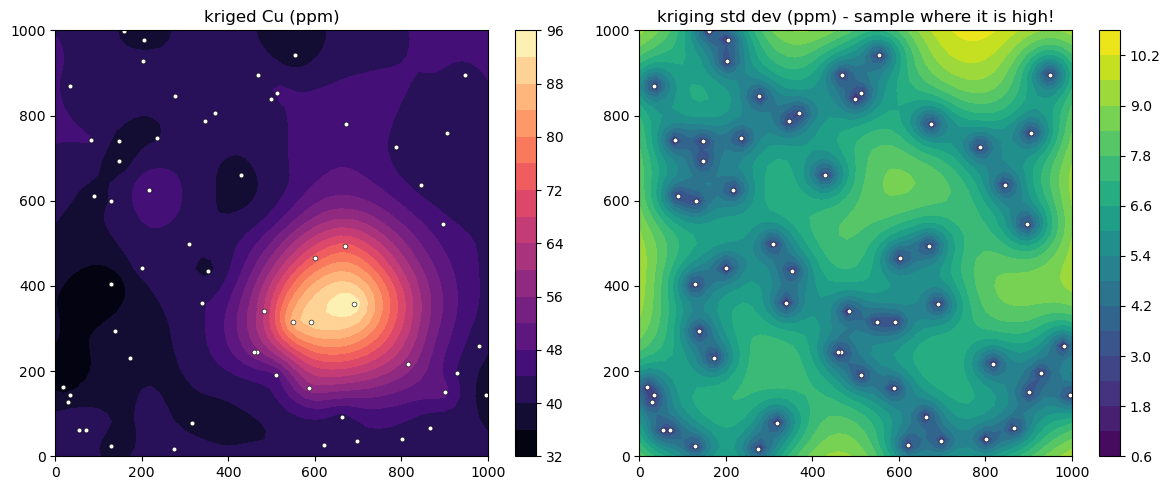

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].contourf(gx, gy, z_est, levels=15, cmap="magma")
axes[0].scatter(x, y, c="white", s=12, edgecolor="k", lw=0.4)
axes[0].set_title("kriged Cu (ppm)"); fig.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(gx, gy, np.sqrt(z_var), levels=15, cmap="viridis")
axes[1].scatter(x, y, c="white", s=12, edgecolor="k", lw=0.4)
axes[1].set_title("kriging std dev (ppm) - sample where it is high!")
fig.colorbar(im1, ax=axes[1])
plt.tight_layout(); plt.show()

## 5. Validate — leave-one-out style spot check

In [6]:
z_at_samples, _ = ok.execute("points", x, y)
resid = z - z_at_samples.data
print("mean abs error at sample points: %.2f ppm" % np.abs(resid).mean())
print("(near zero because kriging is an exact interpolator at data points)")

mean abs error at sample points: 0.00 ppm
(near zero because kriging is an exact interpolator at data points)


### ✏️ Try it
1. Refit with `variogram_model='gaussian'` and `'exponential'` — compare the peak estimate.
2. Reduce to 25 samples and watch the variance map light up.
3. Try `UniversalKriging` with a regional drift term.

📚 Docs: https://geostat-framework.readthedocs.io/projects/pykrige/